<a href="https://colab.research.google.com/github/sanjanasujay/DemandForecast/blob/dev/pghMLproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import xgboost as xgb

import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import xgboost as xgb

import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)


In [3]:
# ==== CONFIG: EDIT THIS PART ====

# Path to your Kaggle dataset CSV file
DATA_PATH = "Product_Sales_Dataset_2023_2024.csv"  # change to your actual file name

# Column names in the raw data (adjust to real names)
DATE_COL       = "Order Date"      # or "Date"
PRODUCT_COL    = "Product Name"    # or "Product", "Product_ID"
SALES_COL      = "Sales"           # or "Total_Sales", "Revenue"
REGION_COL     = "Region"          # or "Country", "State", etc.
CATEGORY_COL   = "Category"        # or "Product_Category", etc.

# Granularity assumptions:
# If your data is at the ORDER level (multiple rows per product per day),
# we will aggregate to daily product-level sales.
AGGREGATE_TO_DAILY = True

# Forecast horizon (in days) beyond the last date in the dataset
FORECAST_HORIZON_DAYS = 30

# ================================


In [5]:
df_raw = pd.read_csv("/content/product_sales_dataset_final.csv")
print("Shape:", df_raw.shape)
df_raw.head()


Shape: (200000, 14)


,Order_ID,Order_Date,Customer_Name,City,State,Region,Country,Category,Sub_Category,Product_Name,Quantity,Unit_Price,Revenue,Profit
0,1,08-23-23,Bianca Brown,Jackson,Mississippi,South,United States,Accessories,Small Electronics,Phone Case,3,201.01,603.03,221.49
1,2,12-20-24,Jared Edwards,Grand Rapids,Michigan,Centre,United States,Accessories,Small Electronics,Charging Cable,4,74.30,297.20,97.09
2,3,01-29-24,Susan Valdez,Minneapolis,Minnesota,Centre,United States,Clothing & Apparel,Sportswear,Nike Air Force 1,1,68.19,68.19,25.47
3,4,11-29-24,Tina Williams,Tallahassee,Florida,South,United States,Clothing & Apparel,Sportswear,Adidas Tracksuit,3,209.64,628.92,231.38
4,5,09-21-23,Catherine Gordon,Baltimore,Maryland,East,United States,Accessories,Bags,Backpack,1,216.63,216.63,42.46


In [6]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Order_ID       200000 non-null  int64  
 1   Order_Date     200000 non-null  object 
 2   Customer_Name  200000 non-null  object 
 3   City           200000 non-null  object 
 4   State          200000 non-null  object 
 5   Region         200000 non-null  object 
 6   Country        200000 non-null  object 
 7   Category       200000 non-null  object 
 8   Sub_Category   200000 non-null  object 
 9   Product_Name   200000 non-null  object 
 10  Quantity       200000 non-null  int64  
 11   Unit_Price    200000 non-null  float64
 12   Revenue       200000 non-null  float64
 13   Profit        200000 non-null  float64
dtypes: float64(3), int64(2), object(9)
memory usage: 21.4+ MB


In [8]:
# ====== STEP 5: Aggregate to Daily Product Sales ======

df = df_raw.copy()

# Clean column names (optional but recommended)
df.columns = df.columns.str.strip()   # removes spaces like " Revenue "
df.rename(columns={"Unit_Price": "Unit_Price"}, inplace=True)

DATE_COL       = "Order_Date"
PRODUCT_COL    = "Product_Name"
SALES_COL      = "Revenue"
REGION_COL     = "Region"
CATEGORY_COL   = "Category"

# Convert to datetime
df[DATE_COL] = pd.to_datetime(df[DATE_COL])

# Aggregate to daily product-level sales
group_cols = [DATE_COL, PRODUCT_COL]

# Your dataset has Region + Category → include them
group_cols.append(REGION_COL)
group_cols.append(CATEGORY_COL)

df_daily = (
    df.groupby(group_cols, as_index=False)[SALES_COL].sum()
)

df_daily = df_daily.sort_values([PRODUCT_COL, DATE_COL]).reset_index(drop=True)

df_daily.head()


,Order_Date,Product_Name,Region,Category,Revenue
0,2023-01-01,Adidas Tracksuit,Centre,Clothing & Apparel,1618.31
1,2023-01-01,Adidas Tracksuit,East,Clothing & Apparel,224.82
2,2023-01-01,Adidas Tracksuit,West,Clothing & Apparel,1020.36
3,2023-01-02,Adidas Tracksuit,Centre,Clothing & Apparel,198.41
4,2023-01-02,Adidas Tracksuit,South,Clothing & Apparel,846.06


In [9]:
# ====== STEP 6: Date Features + Festive Flag ======

df_feat = df_daily.copy()

# Date features
df_feat["year"] = df_feat[DATE_COL].dt.year
df_feat["month"] = df_feat[DATE_COL].dt.month
df_feat["day"] = df_feat[DATE_COL].dt.day
df_feat["dayofweek"] = df_feat[DATE_COL].dt.dayofweek  # Monday=0
df_feat["weekofyear"] = df_feat[DATE_COL].dt.isocalendar().week.astype(int)
df_feat["is_weekend"] = df_feat["dayofweek"].isin([5, 6]).astype(int)

# ---- Festive / Holiday Calendar (example for 2023–2024, adjust if needed) ----
holiday_dates = [
    # 2023
    "2023-11-23",  # Thanksgiving (US)
    "2023-11-24",  # Black Friday
    "2023-12-24", "2023-12-25",  # Christmas Eve & Day
    "2023-12-31", "2024-01-01",  # New Year Eve & Day

    # 2024
    "2024-11-28",  # Thanksgiving
    "2024-11-29",  # Black Friday
    "2024-12-24", "2024-12-25",
    "2024-12-31", "2025-01-01",
]

holiday_dates = pd.to_datetime(holiday_dates)
holiday_window_days = 2  # treat +/- 2 days around each as "festive"

def mark_festive(date_series, holiday_dates, window=2):
    festive = pd.Series(0, index=date_series.index)
    for h in holiday_dates:
        mask = (date_series >= (h - pd.Timedelta(days=window))) & \
               (date_series <= (h + pd.Timedelta(days=window)))
        festive[mask] = 1
    return festive

df_feat["is_festive"] = mark_festive(df_feat[DATE_COL], holiday_dates, window=holiday_window_days)

df_feat.head()


,Order_Date,Product_Name,Region,Category,Revenue,year,month,day,dayofweek,weekofyear,is_weekend,is_festive
0,2023-01-01,Adidas Tracksuit,Centre,Clothing & Apparel,1618.31,2023,1,1,6,52,1,0
1,2023-01-01,Adidas Tracksuit,East,Clothing & Apparel,224.82,2023,1,1,6,52,1,0
2,2023-01-01,Adidas Tracksuit,West,Clothing & Apparel,1020.36,2023,1,1,6,52,1,0
3,2023-01-02,Adidas Tracksuit,Centre,Clothing & Apparel,198.41,2023,1,2,0,1,0,0
4,2023-01-02,Adidas Tracksuit,South,Clothing & Apparel,846.06,2023,1,2,0,1,0,0


In [12]:
# ====== STEP 7: Lag & Rolling Features (FIXED) ======

df_lagged = df_feat.copy()

# Group by product + region + category for time-series lags
group_cols = [PRODUCT_COL, REGION_COL, CATEGORY_COL]

# Sort for safety
df_lagged = df_lagged.sort_values(group_cols + [DATE_COL])

# Lags
lags = [7, 14, 28]
for l in lags:
    df_lagged[f"lag_{l}"] = (
        df_lagged
        .groupby(group_cols)[SALES_COL]
        .shift(l)
    )

# Rolling means on past sales (using transform to keep index aligned)
rolling_windows = [7, 14, 28]
for w in rolling_windows:
    df_lagged[f"roll_mean_{w}"] = (
        df_lagged
        .groupby(group_cols)[SALES_COL]
        .transform(
            lambda s: s.shift(1).rolling(window=w, min_periods=1).mean()
        )
    )

# Drop rows where the largest lag is not available (optional but recommended)
min_lag = max(lags)
df_lagged = df_lagged[df_lagged[f"lag_{min_lag}"].notnull()].reset_index(drop=True)

df_lagged.head()


,Order_Date,Product_Name,Region,Category,Revenue,year,month,day,dayofweek,weekofyear,is_weekend,is_festive,lag_7,lag_14,lag_28,roll_mean_7,roll_mean_14,roll_mean_28
0,2023-02-07,Adidas Tracksuit,Centre,Clothing & Apparel,370.88,2023,2,7,1,6,0,0,1302.48,122.04,1618.31,1394.098571,1262.152143,1004.487500
1,2023-02-10,Adidas Tracksuit,Centre,Clothing & Apparel,123.81,2023,2,10,4,6,0,0,975.60,317.88,198.41,1261.012857,1279.926429,959.936429
2,2023-02-11,Adidas Tracksuit,Centre,Clothing & Apparel,264.56,2023,2,11,5,6,1,0,626.34,2622.01,597.56,1139.328571,1266.064286,957.272143
3,2023-02-13,Adidas Tracksuit,Centre,Clothing & Apparel,236.61,2023,2,13,0,7,0,0,867.84,2629.52,317.64,1087.645714,1097.675000,945.379286
4,2023-02-14,Adidas Tracksuit,Centre,Clothing & Apparel,378.10,2023,2,14,1,7,0,0,1497.86,641.31,327.14,997.470000,926.752857,942.485357


In [13]:
# ====== STEP 8: Train/Test Split (Time-Based) ======

df_lagged = df_lagged.sort_values(DATE_COL).reset_index(drop=True)

max_date = df_lagged[DATE_COL].max()
cutoff_date = max_date - pd.Timedelta(days=90)  # last 90 days as test

print("Max date in data:", max_date)
print("Train/Test cutoff:", cutoff_date)

train_df = df_lagged[df_lagged[DATE_COL] <= cutoff_date].copy()
test_df  = df_lagged[df_lagged[DATE_COL] >  cutoff_date].copy()

print("Train size:", train_df.shape)
print("Test size:", test_df.shape)


Max date in data: 2024-12-31 00:00:00
Train/Test cutoff: 2024-10-02 00:00:00
Train size: (75787, 18)
Test size: (15646, 18)


In [14]:
# ====== STEP 9: Define Features & Target ======

target_col = SALES_COL

numeric_features = [
    "year", "month", "day", "dayofweek", "weekofyear", "is_weekend",
    "is_festive",
] + [f"lag_{l}" for l in lags] + [f"roll_mean_{w}" for w in rolling_windows]

categorical_features = [PRODUCT_COL, REGION_COL, CATEGORY_COL]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

X_train = train_df[numeric_features + categorical_features]
y_train = train_df[target_col]

X_test = test_df[numeric_features + categorical_features]
y_test = test_df[target_col]


Numeric features: ['year', 'month', 'day', 'dayofweek', 'weekofyear', 'is_weekend', 'is_festive', 'lag_7', 'lag_14', 'lag_28', 'roll_mean_7', 'roll_mean_14', 'roll_mean_28']
Categorical features: ['Product_Name', 'Region', 'Category']


In [15]:
# ====== STEP 10: Preprocessing + XGBoost Pipeline ======

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import xgboost as xgb

# One-hot encode categoricals, pass through numerics
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features),
    ]
)

xgb_reg = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", xgb_reg),
])

model


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product_Name', 'Region',
                                                   'Category']),
                                                 ('num', 'passthrough',
                                                  ['year', 'month', 'day',
                                                   'dayofweek', 'weekofyear',
                                                   'is_weekend', 'is_festive',
                                                   'lag_7', 'lag_14', 'lag_28',
                                                   'roll_mean_7',
                                                   'roll_mean_14',
                                                   'roll_mean_28'])])),
                ('regressor',
                 XGBRegressor(base_sc...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=500, n_jobs=-1,
                              num_parallel_tree=None, ...))])

In [16]:
# ====== STEP 11: Train Model ======
%%time
model.fit(X_train, y_train)


CPU times: user 9.44 s, sys: 83.8 ms, total: 9.53 s
Wall time: 6.05 s


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product_Name', 'Region',
                                                   'Category']),
                                                 ('num', 'passthrough',
                                                  ['year', 'month', 'day',
                                                   'dayofweek', 'weekofyear',
                                                   'is_weekend', 'is_festive',
                                                   'lag_7', 'lag_14', 'lag_28',
                                                   'roll_mean_7',
                                                   'roll_mean_14',
                                                   'roll_mean_28'])])),
                ('regressor',
                 XGBRegressor(base_sc...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=500, n_jobs=-1,
                              num_parallel_tree=None, ...))])

In [17]:
# ====== STEP 12: Evaluate on Test Set ======

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-9))) * 100
r2   = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:,.2f}")
print(f"MAE:  {mae:,.2f}")
print(f"MAPE: {mape:,.2f}%")
print(f"R²:   {r2:,.4f}")


RMSE: 1,709.22
MAE:  1,151.48
MAPE: 142.00%
R²:   0.3911


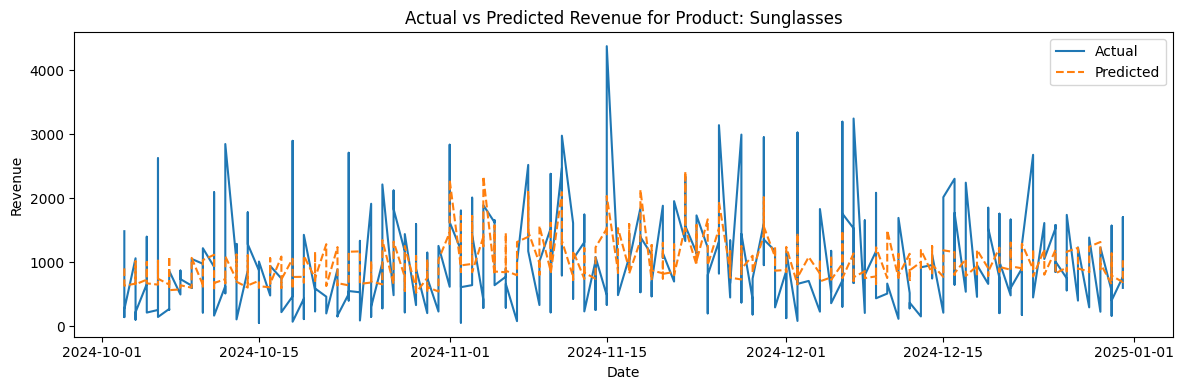

In [18]:
# Plot actual vs predicted for a sample product in test data
sample_product = X_test[PRODUCT_COL].iloc[0]

mask = test_df[PRODUCT_COL] == sample_product
tmp = test_df[mask].copy().sort_values(DATE_COL)
tmp_features = tmp[numeric_features + categorical_features]
tmp["y_pred"] = model.predict(tmp_features)

plt.figure(figsize=(12, 4))
plt.plot(tmp[DATE_COL], tmp[target_col], label="Actual")
plt.plot(tmp[DATE_COL], tmp["y_pred"], label="Predicted", linestyle="--")
plt.title(f"Actual vs Predicted Revenue for Product: {sample_product}")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.tight_layout()
plt.show()


In [19]:
# ====== STEP 13: Build Future Calendar ======

FORECAST_HORIZON_DAYS = 30  # choose your horizon

max_date = df_lagged[DATE_COL].max()
future_dates = pd.date_range(
    start=max_date + pd.Timedelta(days=1),
    periods=FORECAST_HORIZON_DAYS,
    freq="D"
)

print("Last date in data:", max_date)
print("Forecast from:", future_dates.min(), "to", future_dates.max())


Last date in data: 2024-12-31 00:00:00
Forecast from: 2025-01-01 00:00:00 to 2025-01-30 00:00:00


In [20]:
# Unique product-region-category combos
keys_cols = [PRODUCT_COL, REGION_COL, CATEGORY_COL]
unique_keys = df_lagged[keys_cols].drop_duplicates()
unique_keys.head(), unique_keys.shape


(        Product_Name  Region            Category
 0         Sunglasses    West         Accessories
 2    Carter's Onesie    West  Clothing & Apparel
 7       Storage Rack  Centre    Home & Furniture
 8        Apple Watch    East         Electronics
 13  Closet Organizer    East    Home & Furniture,
 (204, 3))

In [21]:
# Build base future frame (all products x future_dates)
future_list = []
for _, row in unique_keys.iterrows():
    for d in future_dates:
        rec = row.to_dict()
        rec[DATE_COL] = d
        future_list.append(rec)

future_df = pd.DataFrame(future_list)

# Add calendar features
future_df["year"] = future_df[DATE_COL].dt.year
future_df["month"] = future_df[DATE_COL].dt.month
future_df["day"] = future_df[DATE_COL].dt.day
future_df["dayofweek"] = future_df[DATE_COL].dt.dayofweek
future_df["weekofyear"] = future_df[DATE_COL].dt.isocalendar().week.astype(int)
future_df["is_weekend"] = future_df["dayofweek"].isin([5, 6]).astype(int)
future_df["is_festive"] = mark_festive(future_df[DATE_COL], holiday_dates, window=holiday_window_days)

future_df.head()


,Product_Name,Region,Category,Order_Date,year,month,day,dayofweek,weekofyear,is_weekend,is_festive
0,Sunglasses,West,Accessories,2025-01-01,2025,1,1,2,1,0,1
1,Sunglasses,West,Accessories,2025-01-02,2025,1,2,3,1,0,1
2,Sunglasses,West,Accessories,2025-01-03,2025,1,3,4,1,0,1
3,Sunglasses,West,Accessories,2025-01-04,2025,1,4,5,1,1,0
4,Sunglasses,West,Accessories,2025-01-05,2025,1,5,6,1,1,0


In [22]:
# Approximate lag & rolling features using last known values per key
lag_roll_cols = [f"lag_{l}" for l in lags] + [f"roll_mean_{w}" for w in rolling_windows]

last_known = (
    df_lagged
    .sort_values(DATE_COL)
    .groupby(keys_cols)
    .tail(1)[keys_cols + lag_roll_cols]
)

future_df = future_df.merge(last_known, on=keys_cols, how="left")

# Fill any NaNs with global means
for col in lag_roll_cols:
    future_df[col] = future_df[col].fillna(df_lagged[col].mean())

future_df.head()


,Product_Name,Region,Category,Order_Date,year,month,day,dayofweek,weekofyear,is_weekend,is_festive,lag_7,lag_14,lag_28,roll_mean_7,roll_mean_14,roll_mean_28
0,Sunglasses,West,Accessories,2025-01-01,2025,1,1,2,1,0,1,1609.93,2301.7,1170.75,1207.215714,1250.31,1258.518571
1,Sunglasses,West,Accessories,2025-01-02,2025,1,2,3,1,0,1,1609.93,2301.7,1170.75,1207.215714,1250.31,1258.518571
2,Sunglasses,West,Accessories,2025-01-03,2025,1,3,4,1,0,1,1609.93,2301.7,1170.75,1207.215714,1250.31,1258.518571
3,Sunglasses,West,Accessories,2025-01-04,2025,1,4,5,1,1,0,1609.93,2301.7,1170.75,1207.215714,1250.31,1258.518571
4,Sunglasses,West,Accessories,2025-01-05,2025,1,5,6,1,1,0,1609.93,2301.7,1170.75,1207.215714,1250.31,1258.518571


In [23]:
# ====== STEP 14: Predict Future Sales (Normal vs Festive) ======

future_X_base = future_df[numeric_features + categorical_features].copy()

# Scenario A: Normal (force is_festive=0)
future_X_normal = future_X_base.copy()
if "is_festive" in future_X_normal.columns:
    future_X_normal["is_festive"] = 0

# Scenario B: Festive (force is_festive=1)
future_X_festive = future_X_base.copy()
if "is_festive" in future_X_festive.columns:
    future_X_festive["is_festive"] = 1

# Predict
future_df["pred_revenue_normal"] = model.predict(future_X_normal)
future_df["pred_revenue_festive"] = model.predict(future_X_festive)

future_df.head()


,Product_Name,Region,Category,Order_Date,year,month,day,dayofweek,weekofyear,is_weekend,is_festive,lag_7,lag_14,lag_28,roll_mean_7,roll_mean_14,roll_mean_28,pred_revenue_normal,pred_revenue_festive
0,Sunglasses,West,Accessories,2025-01-01,2025,1,1,2,1,0,1,1609.93,2301.7,1170.75,1207.215714,1250.31,1258.518571,914.373962,915.847168
1,Sunglasses,West,Accessories,2025-01-02,2025,1,2,3,1,0,1,1609.93,2301.7,1170.75,1207.215714,1250.31,1258.518571,904.945435,906.418640
2,Sunglasses,West,Accessories,2025-01-03,2025,1,3,4,1,0,1,1609.93,2301.7,1170.75,1207.215714,1250.31,1258.518571,929.097900,930.571106
3,Sunglasses,West,Accessories,2025-01-04,2025,1,4,5,1,1,0,1609.93,2301.7,1170.75,1207.215714,1250.31,1258.518571,948.707947,950.181152
4,Sunglasses,West,Accessories,2025-01-05,2025,1,5,6,1,1,0,1609.93,2301.7,1170.75,1207.215714,1250.31,1258.518571,966.967407,968.440613


In [24]:
# ====== STEP 15: Analyze Uplift ======

product_forecast_summary = (
    future_df
    .groupby(PRODUCT_COL)[["pred_revenue_normal", "pred_revenue_festive"]]
    .mean()
    .reset_index()
)

product_forecast_summary["uplift_festive_vs_normal"] = \
    product_forecast_summary["pred_revenue_festive"] - product_forecast_summary["pred_revenue_normal"]

product_forecast_summary.sort_values("uplift_festive_vs_normal", ascending=False).head(10)


,Product_Name,pred_revenue_normal,pred_revenue_festive,uplift_festive_vs_normal
38,Tempur-Pedic Mattress,3478.144531,4062.469727,584.325195
39,Throw Pillows,1490.686401,1662.586304,171.899902
40,Timberland Boots,647.442810,786.118469,138.675659
20,IKEA Sofa,1654.064575,1755.046753,100.982178
3,Ashley Recliner,1050.149048,1125.699585,75.550537
48,iPad Pro,1713.574097,1776.966431,63.392334
15,Dining Table Set,984.383423,1041.152832,56.769409
7,Brooklinen Sheets,1514.568848,1568.699219,54.130371
17,Fitbit Charge,1254.490356,1298.730103,44.239746
21,Instant Pot,1859.926514,1890.209839,30.283325


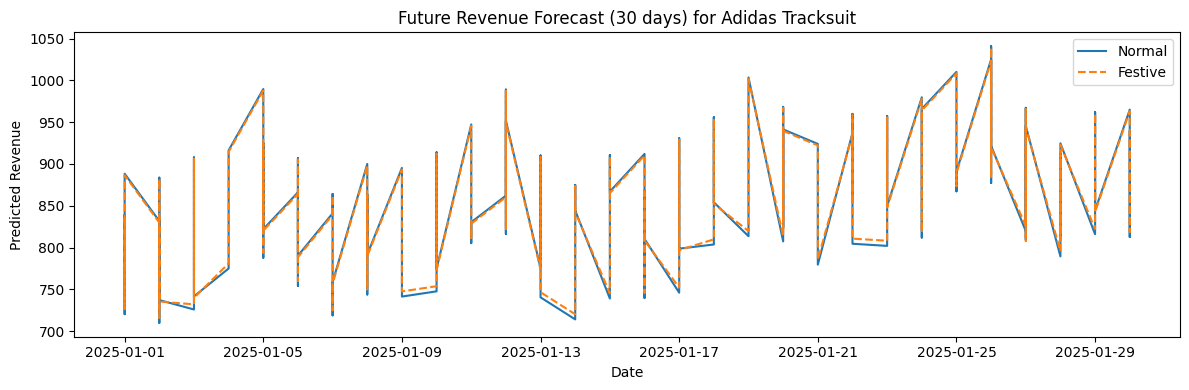

In [25]:
sample_product = product_forecast_summary[PRODUCT_COL].iloc[0]

mask = future_df[PRODUCT_COL] == sample_product
tmp = future_df[mask].copy().sort_values(DATE_COL)

plt.figure(figsize=(12, 4))
plt.plot(tmp[DATE_COL], tmp["pred_revenue_normal"], label="Normal")
plt.plot(tmp[DATE_COL], tmp["pred_revenue_festive"], label="Festive", linestyle="--")
plt.title(f"Future Revenue Forecast ({FORECAST_HORIZON_DAYS} days) for {sample_product}")
plt.xlabel("Date")
plt.ylabel("Predicted Revenue")
plt.legend()
plt.tight_layout()
plt.show()
